In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn import naive_bayes
from sklearn.metrics import roc_auc_score,accuracy_score
import pickle

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
dataset = pd.read_csv('reviews.txt',sep = '\t', names =['Reviews','Comments'])

In [6]:
dataset

,Reviews,Comments
0,1,The Da Vinci Code book is just awesome.
1,1,this was the first clive cussler i've ever rea...
2,1,i liked the Da Vinci Code a lot.
3,1,i liked the Da Vinci Code a lot.
4,1,I liked the Da Vinci Code but it ultimatly did...
...,...,...
6913,0,Brokeback Mountain was boring.
6914,0,So Brokeback Mountain was really depressing.
6915,0,"As I sit here, watching the MTV Movie Awards, ..."
6916,0,Ok brokeback mountain is such a horrible movie.


In [7]:
stopset = stopwords.words('english')

In [8]:
vectorizer = TfidfVectorizer(use_idf = True,lowercase = True, strip_accents='ascii',stop_words=stopset)

In [9]:
X = vectorizer.fit_transform(dataset.Comments)
y = dataset.Reviews
pickle.dump(vectorizer, open('tranform.pkl', 'wb'))

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [11]:
clf = naive_bayes.MultinomialNB()
clf.fit(X_train,y_train)

MultinomialNB()

In [12]:
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, clf.predict(X_test))*100))

Accuracy: 97.47%


In [13]:
clf = naive_bayes.MultinomialNB()
clf.fit(X,y)

MultinomialNB()

In [14]:
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, clf.predict(X_test))*100))

Accuracy: 98.77%


In [15]:
filename = 'nlp_model.pkl'
pickle.dump(clf, open(filename, 'wb'))

[[566  14]
 [  3 801]]


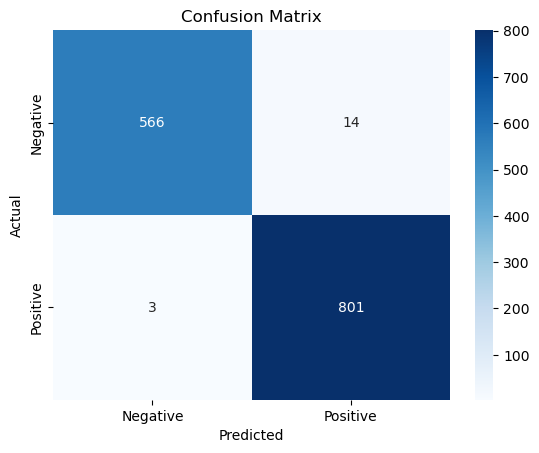

Accuracy: 98.77%


In [16]:
y_pred = clf.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
print("Accuracy: {:.2f}%".format(accuracy_score(y_test, clf.predict(X_test))*100))

In [1]:
import os

# Get the current working directory
cwd = os.getcwd()
print(f"Current Directory: {cwd}")

# List all files in the current directory (to check for your csv/pkl files)
files = os.listdir('.')
print(f"Files in directory: {files}")

Current Directory: C:\Users\HP\movie_recommendation_system
Files in directory: ['.ipynb_checkpoints', 'all_movies_clean.csv', 'credits.csv', 'data.csv', 'main.py', 'main_data.csv', 'movies_2018_clean.csv', 'movies_2020_clean.csv', 'movies_2021_clean.csv', 'movies_2022_clean.csv', 'movies_2023_clean.csv', 'movies_2024_clean.csv', 'movies_2025_clean.csv', 'movies_metadata.csv', 'movie_metadata.csv', 'new_data.csv', 'nlp_model.pkl', 'preprocessing 1.ipynb', 'preprocessing 2.ipynb', 'preprocessing 3.ipynb', 'preprocessing_4.ipynb', 'Procfile', 'README.md', 'requirements.txt', 'reviews.txt', 'sentiment.ipynb', 'static', 'templates', 'tranform.pkl', 'Untitled.ipynb']
